In [86]:
# Import important libraries

import pandas as pd
import numpy as np
import json

In [87]:
# JSON file

path = r"c:\\Users\\EHU_HEALTH_TECHNICAL\\Documents\\Khing_FM_Data_Science\\Data_Science\assets\ts-academy_datasets\\products.json"

# Load the raw JSON file
with open(path, "r") as file:
    products_json = json.load(file)

print(type(products_json))
print(products_json.keys())

<class 'dict'>
dict_keys(['catalog_version', 'last_updated', 'currency', 'categories'])


In [88]:
df = products_json

In [89]:
print(type(df))
print(df.keys())

<class 'dict'>
dict_keys(['catalog_version', 'last_updated', 'currency', 'categories'])


In [90]:
# Create a list for the flattened product records
product_records = []

for category, category_data in df['categories'].items():

    for product in category_data['products']:

        product_records.append({
            'category': category,
            'sku': product['sku'],
            'product': product['name'],
            'price': product['price'],
            'stock': product['inventory']['stock'],
            'reorder_point': product['inventory']['reorder_point'],
            'supplier_id': product['inventory']['supplier_id'],
            'rating': product['ratings']['average'],
            'rating_count': product['ratings']['count'],
            'active': product['active']
        })

# Convert to DataFrame
df = pd.DataFrame(product_records)

display(df.head())

,category,sku,product,price,stock,reorder_point,supplier_id,rating,rating_count,active
0,Electronics,ELEC-001,Laptop Pro 15,1299.99,45,10,SUP-518,4.5,234,True
1,Electronics,ELEC-002,Wireless Mouse,29.99,350,70,SUP-632,4.2,892,True
2,Electronics,ELEC-003,USB-C Dock,89.99,120,24,SUP-654,4.0,156,True
3,Electronics,ELEC-004,Mechanical Keyboard,149.99,78,15,SUP-818,4.7,445,True
4,Electronics,ELEC-005,"4K Monitor 32""",449.99,32,10,SUP-982,4.6,289,True


In [91]:
print(f"Unique categories: {df['category'].unique()}")
print(f"Number of unique products: {df['product'].nunique()}")
print(f"Number of unique suppliers: {df['supplier_id'].nunique()}")

Unique categories: <ArrowStringArray>
['Electronics', 'Furniture', 'Office Supplies']
Length: 3, dtype: str
Number of unique products: 19
Number of unique suppliers: 17


In [ ]:
# 1. Basic information about the dataset

print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nFirst 5 rows:")
display(df.head())

print("\nLast 5 rows:")
display(df.tail())

Shape: (19, 10)

Columns:
['category', 'sku', 'product', 'price', 'stock', 'reorder_point', 'supplier_id', 'rating', 'rating_count', 'active']

Data types:
category             str
sku                  str
product              str
price            float64
stock              int64
reorder_point      int64
supplier_id          str
rating           float64
rating_count       int64
active              bool
dtype: object

First 5 rows:


,category,sku,product,price,stock,reorder_point,supplier_id,rating,rating_count,active
0,Electronics,ELEC-001,Laptop Pro 15,1299.99,45,10,SUP-518,4.5,234,True
1,Electronics,ELEC-002,Wireless Mouse,29.99,350,70,SUP-632,4.2,892,True
2,Electronics,ELEC-003,USB-C Dock,89.99,120,24,SUP-654,4.0,156,True
3,Electronics,ELEC-004,Mechanical Keyboard,149.99,78,15,SUP-818,4.7,445,True
4,Electronics,ELEC-005,"4K Monitor 32""",449.99,32,10,SUP-982,4.6,289,True



Last 5 rows:


,category,sku,product,price,stock,reorder_point,supplier_id,rating,rating_count,active
14,Office Supplies,OFFC-002,Gel Pen Set 12-Pack,15.99,800,160,SUP-109,4.5,567,True
15,Office Supplies,OFFC-003,Printer Paper Ream,29.99,1200,240,SUP-202,4.0,123,True
16,Office Supplies,OFFC-004,Desk Organizer Set,34.99,180,36,SUP-260,4.4,298,True
17,Office Supplies,OFFC-005,Whiteboard 36x24,59.99,65,13,SUP-893,4.1,89,True
18,Office Supplies,OFFC-006,Label Maker,39.99,95,19,SUP-626,4.2,345,True


In [ ]:
# 2a. Count products by category

category_counts = df['category'].value_counts()
print("\nProduct counts by category:")
print(category_counts)


Product counts by category:
category
Electronics        8
Office Supplies    6
Furniture          5
Name: count, dtype: int64


<Axes: title={'center': 'Number of Products by Category'}, xlabel='Category', ylabel='Number of Products'>

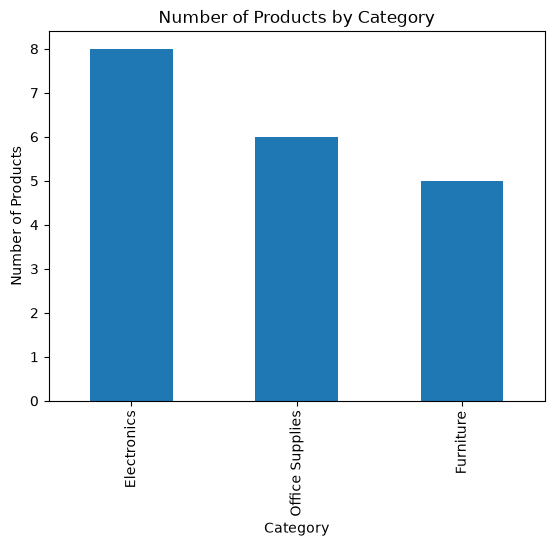

In [ ]:
# 2b. Visualize the distribution of products by category

category_counts.plot(
    kind='bar',
    title='Number of Products by Category',
    xlabel='Category',
    ylabel='Number of Products'
)

In [ ]:
# 3a. Calculate price statistics

print("Average price:", df['price'].mean())
print("Minimum price:", df['price'].min())
print("Maximum price:", df['price'].max())
print("Median price:", df['price'].median())
print("Price standard deviation:", df['price'].std())

Average price: 218.20052631578946
Minimum price: 15.99
Maximum price: 1299.99
Median price: 119.99
Price standard deviation: 308.96827937640904


In [ ]:
# 3b. Or a quick summary of the price column
df['price'].describe()

count      19.000000
mean      218.200526
std       308.968279
min        15.990000
25%        37.490000
50%       119.990000
75%       234.990000
max      1299.990000
Name: price, dtype: float64

In [ ]:
# 4. Most expensive products

expensive_products = df.sort_values(
    by='price',
    ascending=False
)

display(
expensive_products[
    ['category', 'sku', 'product', 'price', 'stock', 'supplier_id']
].head(5)
)

display(
expensive_products[
    ['product', 'category', 'price']
].head(5)
)

,category,sku,product,price,stock,supplier_id
0,Electronics,ELEC-001,Laptop Pro 15,1299.99,45,SUP-518
9,Furniture,FURN-002,Standing Desk Electric,599.99,15,SUP-396
4,Electronics,ELEC-005,"4K Monitor 32""",449.99,32,SUP-982
8,Furniture,FURN-001,Ergonomic Office Chair,399.99,28,SUP-330
6,Electronics,ELEC-007,Noise Canceling Headphones,279.99,67,SUP-280


,product,category,price
0,Laptop Pro 15,Electronics,1299.99
9,Standing Desk Electric,Furniture,599.99
4,"4K Monitor 32""",Electronics,449.99
8,Ergonomic Office Chair,Furniture,399.99
6,Noise Canceling Headphones,Electronics,279.99


In [ ]:
# 5. Lets find cheapest products

cheapest_products = df.sort_values(
    by='price'
)

display(
    cheapest_products[
        ['product', 'category', 'price']
    ].head()
)

,product,category,price
14,Gel Pen Set 12-Pack,Office Supplies,15.99
13,Premium Notebook 5-Pack,Office Supplies,24.99
1,Wireless Mouse,Electronics,29.99
15,Printer Paper Ream,Office Supplies,29.99
16,Desk Organizer Set,Office Supplies,34.99


In [100]:
# 6. Analyze inventory (Which stock needs to be reordered)

low_stock = df[
    df['stock'] <= df['reorder_point']
]

display(
    low_stock[
        [
            'product',
            'category',
            'stock',
            'reorder_point'
        ]
    ]
)

,product,category,stock,reorder_point


In [102]:
# 7b. Calculate inventory value

df['inventory_value'] = (
    df['stock'] * df['price']
)

display(
    df[
        [
            'product',
            'category',
            'stock',
            'price',
            'inventory_value'
        ]
    ]
)

# 7b. Calculate total

total_inventory_value = df['inventory_value'].sum()

print(
    f"Total inventory value: ${total_inventory_value:,.2f}"
)

,product,category,stock,price,inventory_value
0,Laptop Pro 15,Electronics,45,1299.99,58499.55
1,Wireless Mouse,Electronics,350,29.99,10496.50
2,USB-C Dock,Electronics,120,89.99,10798.80
3,Mechanical Keyboard,Electronics,78,149.99,11699.22
4,"4K Monitor 32""",Electronics,32,449.99,14399.68
5,Webcam HD Pro,Electronics,95,129.99,12349.05
6,Noise Canceling Headphones,Electronics,67,279.99,18759.33
7,Portable SSD 1TB,Electronics,145,119.99,17398.55
8,Ergonomic Office Chair,Furniture,28,399.99,11199.72
9,Standing Desk Electric,Furniture,15,599.99,8999.85


Total inventory value: $273,099.08


In [ ]:
# 8a. Inventory value by category

inventory_by_category = (
    df.groupby('category')['inventory_value']
    .sum()
    .sort_values(ascending=False)
)

print(inventory_by_category)

# 8b. Let's try other calculations

category_summary = df.groupby('category').agg(
    number_of_products=('product', 'count'),
    average_price=('price', 'mean'),
    total_stock=('stock', 'sum'),
    inventory_value=('inventory_value', 'sum'),
    average_rating=('rating', 'mean')
)

display(category_summary)

category
Electronics        154400.68
Office Supplies     75271.60
Furniture           43426.80
Name: inventory_value, dtype: float64


,number_of_products,average_price,total_stock,inventory_value,average_rating
category,,,,,
Electronics,8,318.740000,932,154400.68,4.4375
Furniture,5,277.990000,320,43426.80,4.2600
Office Supplies,6,34.323333,2840,75271.60,4.2500


In [ ]:
# 9. Ratings Analysis

top_rated = df.sort_values(
    by='rating',
    ascending=False
)

display(
    top_rated[
        [
            'product',
            'category',
            'rating',
            'rating_count'
        ]
    ].head(5)
)

,product,category,rating,rating_count
6,Noise Canceling Headphones,Electronics,4.8,1203
3,Mechanical Keyboard,Electronics,4.7,445
4,"4K Monitor 32""",Electronics,4.6,289
9,Standing Desk Electric,Furniture,4.6,189
8,Ergonomic Office Chair,Furniture,4.5,312


In [105]:
# 10. Poorly rated products

low_rated = df[
    df['rating'] < 4.2
]

display(
    low_rated[
        [
            'product',
            'category',
            'rating',
            'rating_count'
        ]
    ]
)

,product,category,rating,rating_count
2,USB-C Dock,Electronics,4.0,156
10,LED Desk Lamp,Furniture,4.1,423
11,Filing Cabinet 3-Drawer,Furniture,3.9,87
15,Printer Paper Ream,Office Supplies,4.0,123
17,Whiteboard 36x24,Office Supplies,4.1,89


In [106]:
# 11. Products with most customer reviews

most_reviewed = df.sort_values(
    by='rating_count',
    ascending=False
)

display(
    most_reviewed[
        [
            'product',
            'rating',
            'rating_count'
        ]
    ].head(10)
)

,product,rating,rating_count
6,Noise Canceling Headphones,4.8,1203
1,Wireless Mouse,4.2,892
7,Portable SSD 1TB,4.4,678
5,Webcam HD Pro,4.3,567
14,Gel Pen Set 12-Pack,4.5,567
3,Mechanical Keyboard,4.7,445
10,LED Desk Lamp,4.1,423
18,Label Maker,4.2,345
8,Ergonomic Office Chair,4.5,312
16,Desk Organizer Set,4.4,298


In [107]:
# 12a. Suppliers with most products

supplier_counts = (
    df['supplier_id']
    .value_counts()
)

print(supplier_counts)

supplier_id
SUP-219    2
SUP-330    2
SUP-518    1
SUP-632    1
SUP-654    1
SUP-818    1
SUP-982    1
SUP-280    1
SUP-488    1
SUP-396    1
SUP-129    1
SUP-682    1
SUP-109    1
SUP-202    1
SUP-260    1
SUP-893    1
SUP-626    1
Name: count, dtype: int64


In [108]:
# or 

supplier_summary = df.groupby('supplier_id').agg(
    number_of_products=('product', 'count'),
    total_stock=('stock', 'sum'),
    inventory_value=('inventory_value', 'sum'),
    average_rating=('rating', 'mean')
).sort_values(
    by='number_of_products',
    ascending=False
)

display(supplier_summary)

,number_of_products,total_stock,inventory_value,average_rating
supplier_id,,,,
SUP-219,2,130,17598.70,4.25
SUP-330,2,70,19179.30,4.20
SUP-109,1,800,12792.00,4.50
SUP-202,1,1200,35988.00,4.00
SUP-129,1,200,9998.00,4.10
SUP-260,1,180,6298.20,4.40
SUP-280,1,67,18759.33,4.80
SUP-396,1,15,8999.85,4.60
SUP-488,1,145,17398.55,4.40
